## Data Description

The full description and source can be found here: https://www.kaggle.com/datasets/milanzdravkovic/pharma-sales-data

The dataset was built from an original dataset containing 600,000 transactional records collected over 6 years (2014–2019), indicating the date and time of sale, pharmaceutical drug brand, and quantity sold, exported from each pharmacy’s system.

The selected group of medicines in the dataset (57 drugs) is classified according to the following categories of the Anatomical Therapeutic Chemical (ATC) classification system:

- M01AB – Anti-inflammatory and anti-rheumatic products, non-steroids, acetic acid derivatives and related substances
- M01AE – Anti-inflammatory and anti-rheumatic products, non-steroids, propionic acid derivatives
- N02BA – Other analgesics and antipyretics, salicylic acid and derivatives
- N02BE/B – Other analgesics and antipyretics, pyrazolones and anilides
- N05B – Psycholeptic drugs, anxiolytic medications
- N05C – Psycholeptic drugs, hypnotics and sedatives
- R03 – Drugs for obstructive airway dis

## Project Questions

1. What are the total sales quantities for each drug category (ATC code)?

2. Which individual drug brands have the highest total sales?

3. Which three drugs have the highest sales in January 2015, July 2016, September 2017.

4. Which drug has sold the most often in 2017?

5. Which drug category has the highest average daily sales?

6. Are respiratory drugs (R03) sold more during specific months?

### Importing the data

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
url = '/content/drive/MyDrive/datasets/pharma_sales/salesdaily.csv'

In [88]:
df = pd.read_csv(url)
df.head(20)

,datum,M01AB,M01AE,N02BA,N02BE,N05B,N05C,R03,R06,Year,Month,Hour,Weekday Name
0,1/2/2014,0.00,3.67,3.4,32.40,7.0,0.0,0.0,2.0,2014,1,248,Thursday
1,1/3/2014,8.00,4.00,4.4,50.60,16.0,0.0,20.0,4.0,2014,1,276,Friday
2,1/4/2014,2.00,1.00,6.5,61.85,10.0,0.0,9.0,1.0,2014,1,276,Saturday
3,1/5/2014,4.00,3.00,7.0,41.10,8.0,0.0,3.0,0.0,2014,1,276,Sunday
4,1/6/2014,5.00,1.00,4.5,21.70,16.0,2.0,6.0,2.0,2014,1,276,Monday
5,1/7/2014,0.00,0.00,0.0,0.00,0.0,0.0,0.0,0.0,2014,1,276,Tuesday
6,1/8/2014,5.33,3.00,10.5,26.40,19.0,1.0,10.0,0.0,2014,1,276,Wednesday
7,1/9/2014,7.00,1.68,8.0,25.00,16.0,0.0,3.0,2.0,2014,1,276,Thursday
8,1/10/2014,5.00,2.00,2.0,53.30,15.0,2.0,0.0,2.0,2014,1,276,Friday
9,1/11/2014,5.00,4.34,10.4,52.30,14.0,0.0,1.0,0.2,2014,1,276,Saturday


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2106 entries, 0 to 2105
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   datum         2106 non-null   object 
 1   M01AB         2106 non-null   float64
 2   M01AE         2106 non-null   float64
 3   N02BA         2106 non-null   float64
 4   N02BE         2106 non-null   float64
 5   N05B          2106 non-null   float64
 6   N05C          2106 non-null   float64
 7   R03           2106 non-null   float64
 8   R06           2106 non-null   float64
 9   Year          2106 non-null   int64  
 10  Month         2106 non-null   int64  
 11  Hour          2106 non-null   int64  
 12  Weekday Name  2106 non-null   object 
dtypes: float64(8), int64(3), object(2)
memory usage: 214.0+ KB


In [ ]:
df.describe()

,M01AB,M01AE,N02BA,N02BE,N05B,N05C,R03,R06,Year,Month,Hour
count,2106.000000,2106.000000,2106.000000,2106.000000,2106.000000,2106.000000,2106.000000,2106.000000,2106.000000,2106.000000,2106.000000
mean,5.033683,3.895830,3.880441,29.917095,8.853627,0.593522,5.512262,2.900198,2016.401235,6.344255,275.945869
std,2.737579,2.133337,2.384010,15.590966,5.605605,1.092988,6.428736,2.415816,1.665060,3.386954,1.970547
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2014.000000,1.000000,190.000000
25%,3.000000,2.340000,2.000000,19.000000,5.000000,0.000000,1.000000,1.000000,2015.000000,3.000000,276.000000
50%,4.990000,3.670000,3.500000,26.900000,8.000000,0.000000,4.000000,2.000000,2016.000000,6.000000,276.000000
75%,6.670000,5.138000,5.200000,38.300000,12.000000,1.000000,8.000000,4.000000,2018.000000,9.000000,276.000000
max,17.340000,14.463000,16.000000,161.000000,54.833333,9.000000,45.000000,15.000000,2019.000000,12.000000,276.000000


In [ ]:
df.isnull().sum().sort_values(ascending=False)

,0
datum,0
M01AB,0
M01AE,0
N02BA,0
N02BE,0
N05B,0
N05C,0
R03,0
R06,0
Year,0


In [ ]:
df.duplicated().sum()

np.int64(0)

### Data Cleaning

In [ ]:
df['datum'] = pd.to_datetime(df['datum'], format ='%m/%d/%Y')
df.dtypes

,0
datum,datetime64[ns]
M01AB,float64
M01AE,float64
N02BA,float64
N02BE,float64
N05B,float64
N05C,float64
R03,float64
R06,float64
Year,int64


### Exploratory Data Analysis

In [ ]:
sales = df.drop(columns=['datum', 'Year', 'Month', 'Hour', 'Weekday Name'])
sales

,M01AB,M01AE,N02BA,N02BE,N05B,N05C,R03,R06
0,0.00,3.670,3.40,32.40,7.0,0.0,0.0,2.00
1,8.00,4.000,4.40,50.60,16.0,0.0,20.0,4.00
2,2.00,1.000,6.50,61.85,10.0,0.0,9.0,1.00
3,4.00,3.000,7.00,41.10,8.0,0.0,3.0,0.00
4,5.00,1.000,4.50,21.70,16.0,2.0,6.0,2.00
...,...,...,...,...,...,...,...,...
2101,7.34,5.683,2.25,22.45,13.0,0.0,1.0,1.00
2102,3.84,5.010,6.00,25.40,7.0,0.0,0.0,0.33
2103,4.00,11.690,2.00,34.60,6.0,0.0,5.0,4.20
2104,7.34,4.507,3.00,50.80,6.0,0.0,10.0,1.00


In [ ]:
sales_quantity = sales.sum().sort_values()
sales_quantity

,0
N05C,1249.958333
R06,6107.817500
N02BA,8172.209000
M01AE,8204.618646
M01AB,10600.937083
R03,11608.822917
N05B,18645.737500
N02BE,63005.402708


### Total Sales Quantity for Each Drug Category

([0, 1, 2, 3, 4, 5, 6, 7],
 [Text(0, 0, 'N05C'),
  Text(1, 0, 'R06'),
  Text(2, 0, 'N02BA'),
  Text(3, 0, 'M01AE'),
  Text(4, 0, 'M01AB'),
  Text(5, 0, 'R03'),
  Text(6, 0, 'N05B'),
  Text(7, 0, 'N02BE')])

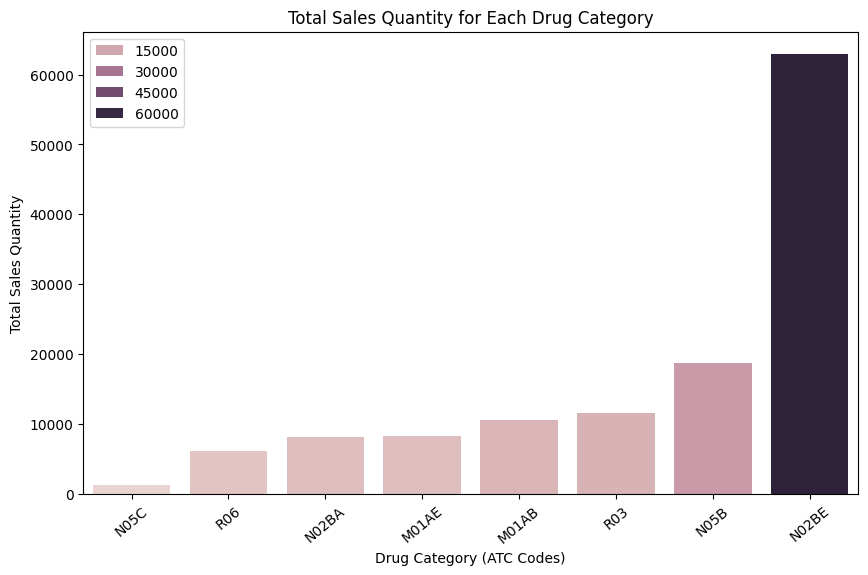

In [ ]:
# Visualisation
plt.figure(figsize=(10, 6))
sns.barplot(x = sales_quantity.index, y = sales_quantity.values, hue = sales_quantity.values)
plt.title("Total Sales Quantity for Each Drug Category")
plt.xlabel("Drug Category (ATC Codes)")
plt.ylabel("Total Sales Quantity")
plt.xticks(rotation=40)

### The drugs have the highest sales in January 2015, July 2016, September 2017


In [ ]:
sales_jan_2015 = df[(df['Year'] == 2015) & (df['Month'] == 1)]
top_sales_jan_2015 = sales_jan_2015.iloc[:,1:9].sum().nlargest(3)

sales_july_2016 = df[(df['Year'] == 2016) & (df['Month'] == 7)]
top_sales_july_2016 = sales_july_2016.iloc[:,1:9].sum().nlargest(3)

sales_sept_2017 = df[(df['Year'] == 2017) & (df['Month'] == 9)]
top_sales_sept_2017 = sales_sept_2017.iloc[:,1:9].sum().nlargest(3)

Text(0.5, 1.0, 'Top 3 drugs in Sept 2017')

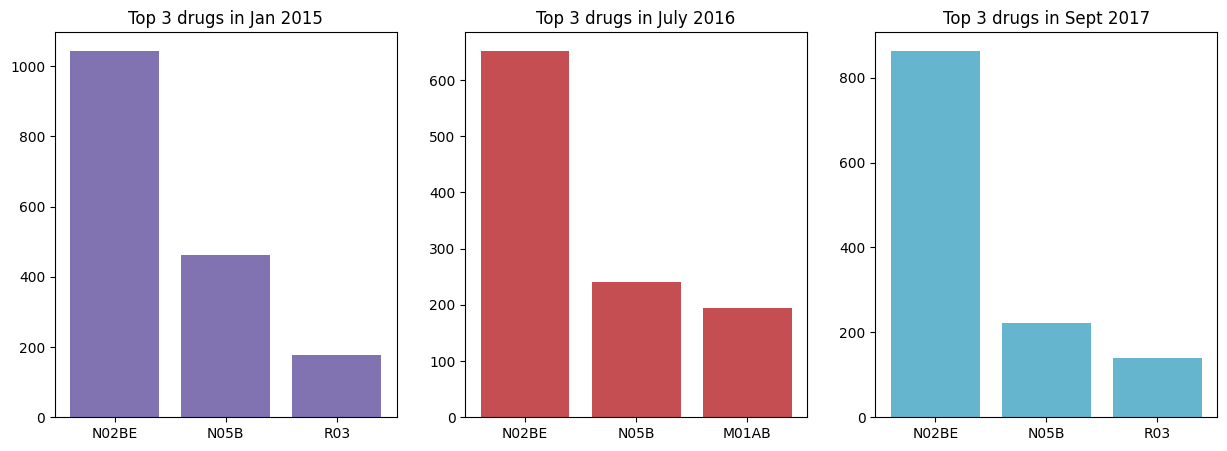

In [ ]:
# Plot 3 bar plots at once
fig, axes = plt.subplots(1, 3, figsize=(15,5))

axes[0].bar(top_sales_jan_2015.index, top_sales_jan_2015.values, color='#8172B2')
axes[0].set_title('Top 3 drugs in Jan 2015')
axes[1].bar(top_sales_july_2016.index, top_sales_july_2016.values, color='#C44E52')
axes[1].set_title('Top 3 drugs in July 2016')
axes[2].bar(top_sales_sept_2017.index, top_sales_sept_2017.values, color='#64B5CD')
axes[2].set_title('Top 3 drugs in Sept 2017')


### Drug that sold the most often in 2017

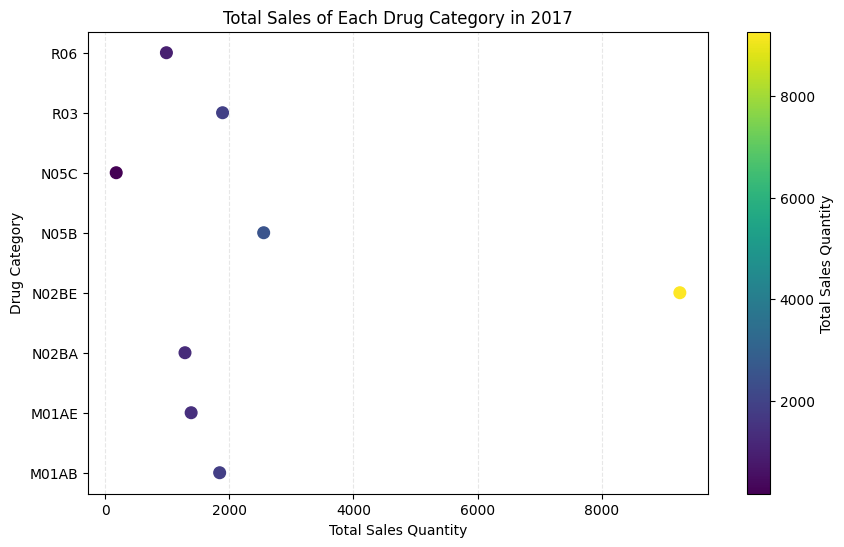

In [ ]:
sales_2017 = df[df['Year']== 2017]
top_sales_2017 = sales_2017.iloc[:,1:9].sum()
plt.figure(figsize=(10,6))
plt.scatter(top_sales_2017.values, top_sales_2017.index, s = 70, c = top_sales_2017.values, cmap = 'viridis')
plt.grid(axis='x', linestyle='--', alpha=0.3)
plt.title('Total Sales of Each Drug Category in 2017')
plt.xlabel('Total Sales Quantity')
plt.ylabel('Drug Category')
plt.colorbar(label='Total Sales Quantity')
plt.show()

### Drug category that has the highest average daily sales

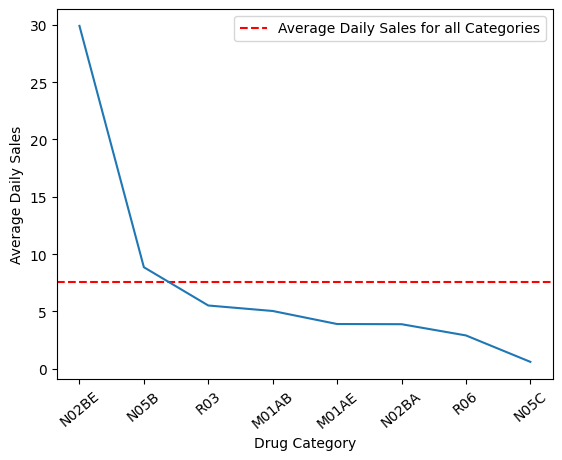

In [99]:
daily_sales = sales.mean().sort_values(ascending=False).reset_index()
daily_sales.columns = ['Drug Category', 'Average Daily Sales']
overall_mean = sales.values.mean()
plt.axhline(overall_mean, color="red", linestyle="--", label="Average Daily Sales for all Categories")
sns.lineplot(data=daily_sales, x = 'Drug Category', y = 'Average Daily Sales')
plt.xticks(rotation=40)
plt.xlabel('Drug Category')
plt.ylabel('Average Daily Sales')
plt.show()


### Monthly Sales of R03

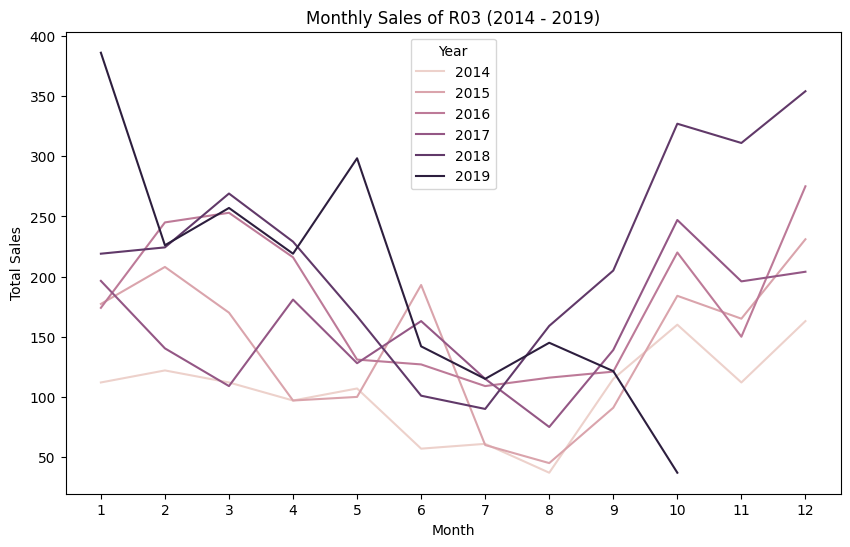

In [111]:
monthly_sales_r03 = df.groupby(['Year', 'Month'])['R03'].sum().reset_index()
plt.figure(figsize=(10,6))
sns.lineplot(data=monthly_sales_r03, x='Month', y='R03', hue='Year')
plt.xticks(range(1, 13)) # Force all months
plt.title('Monthly Sales of R03 (2014 - 2019)')
plt.xlabel('Month')
plt.ylabel('Total Sales')
plt.show()

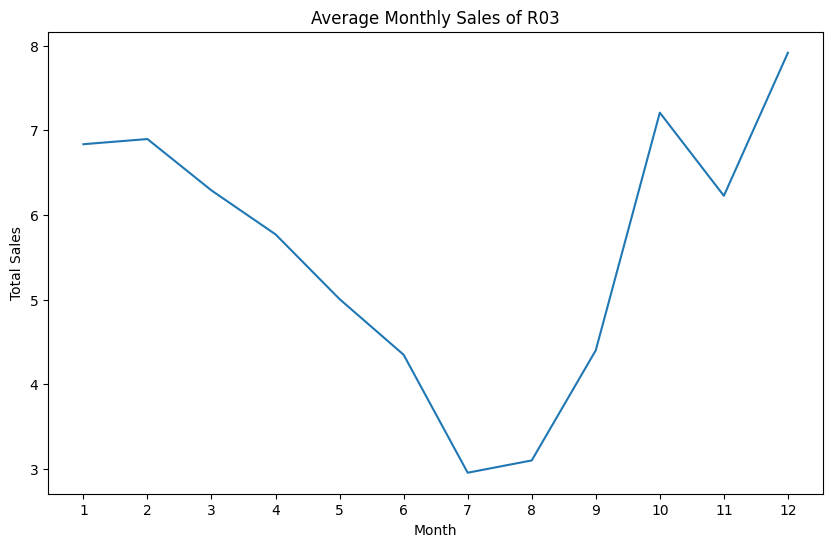

In [110]:
average_monthly_sales_r03 = df.groupby(['Month'])['R03'].mean().reset_index()
plt.figure(figsize=(10,6))
sns.lineplot(data=average_monthly_sales_r03, x='Month', y='R03')
plt.xticks(range(1, 13)) # Force all months
plt.title('Average Monthly Sales of R03')
plt.xlabel('Month')
plt.ylabel('Total Sales')
plt.show()

### Conclusion
The individual drug brand with the highest total sales is N02BE, indicating it consistently outperforms the other categories in overall demand across the dataset.

The top three drugs vary slightly across selected months. In January 2015, the highest-selling drugs are N02BE, N05B, and R03. In July 2016, the top three are N02BE, N05B, and M01AB, while in September 2017, the leading drugs are N02BE, N05B, and R03.

In 2017, the drug that was sold most frequently is N02BE, making it the most dominant category for that year in terms of total sales volume.

The drug category with the highest average daily sales is also N02BE, indicating that it not only performs well in total yearly sales but also maintains consistently high daily demand.

Respiratory drugs (R03) appear to show higher sales during specific periods, with a noticeable increase in October, suggesting a potential seasonal pattern in demand likely linked to respiratory illnesses.